# 0. 환경설정

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['font.family'] = 'Malgun Gothic'  # 한글 깨짐 방지 (Windows)
plt.rcParams['axes.unicode_minus'] = False

# 1. 개요 — 관측창(기간)을 정해야 하는 이유

이 노트북은 여러 후보 일수(7·14·21·28·35·42·49·56일)를 비교해, 관측창을 몇 일로 정하는 것이 근거 있는 선택인지 살펴본다. 네 가지 각도에서 접근한다.
임의로 28일을 선정한 후 다음과 같은 사항을 확인한다

1. **커리큘럼상 자연스러운 경계가 있는가** — 과목별 첫 평가 마감일 분포를 보고 실제 학사 일정과 맞아떨어지는지 확인한다.
2. **관측창별 censoring(조기 이탈로 인한 관측 부족) 비율** — 관측창이 끝나기도 전에 이미 이탈해버린 학생이 얼마나 되는지, 관측창이 길어질수록 이 문제가 어떻게 변하는지 본다.
3. **관측창별 온라인 활동 신호 강도** — VLE 클릭 수 기준으로 완주/이탈 그룹의 격차(효과크기)가 관측창 길이에 따라 어떻게 변하는지 본다.
4. **관측창별 미제출 평가 신호 강도** — 05·06번에서 가장 강력했던 신호인 "미제출 평가 weight"가 관측창 길이에 따라 어떻게 변하는지 본다.

이번 분석에서 "28일이 정답이다"라고 결론 내리는 것이 목표가 아니라, 어떤 근거로 관측창을 정하든 그 근거를 표로 남기는 것이 목표다. 최종 확정은 이 결과를 팀원들과 공유한 뒤 함께 정한다.

# 2. 데이터 로드 및 후보 관측창 설정

In [2]:
info = pd.read_csv('../../CSV_files/studentInfo.csv')
info['label_churn'] = (info['final_result'] == 'Withdrawn').astype(int)

sa = pd.read_csv('../../CSV_files/studentAssessment.csv')
asm = pd.read_csv('../../CSV_files/assessments.csv')
courses = pd.read_csv('../../CSV_files/courses.csv')
reg = pd.read_csv('../../CSV_files/studentRegistration.csv')
vle = pd.read_csv('../../CSV_files/studentVle.csv')

# 학생-과목 단위 roster + 등록/취소 시점
roster = info[['code_module', 'code_presentation', 'id_student', 'label_churn', 'final_result']].drop_duplicates()
roster = roster.merge(reg[['code_module', 'code_presentation', 'id_student', 'date_registration', 'date_unregistration']],
                       on=['code_module', 'code_presentation', 'id_student'], how='left')

# 05·06번과 동일한 기준 제출 조인 테이블
df = sa.merge(asm, on='id_assessment', how='left')
df = df.merge(info[['code_module', 'code_presentation', 'id_student', 'final_result', 'label_churn']],
              on=['code_module', 'code_presentation', 'id_student'], how='left')

# 비교할 후보 관측창(일)
candidates = [7, 14, 21, 28, 35, 42, 49, 56]

print(f'info: {len(info):,}건 / roster: {len(roster):,}건 / 후보 관측창: {candidates}')

info: 32,593건 / roster: 32,593건 / 후보 관측창: [7, 14, 21, 28, 35, 42, 49, 56]


## Q1. 커리큘럼상 자연스러운 경계가 있는가 — 첫 평가 마감일 분포

#### 배경

28일이 순전히 임의의 숫자가 아니라면, 실제 학사 일정(과목별 첫 과제 마감일)과 어느 정도 맞아떨어져야 한다. Exam은 04·05번에서부터 구조적으로 제외해온 기준을 그대로 따라 TMA/CMA만 본다.

In [3]:
# 근거 : 과목-학기별 첫 TMA/CMA 마감일(Exam 제외) 분포
noexam = asm[asm['assessment_type'] != 'Exam']
first_deadline = noexam.groupby(['code_module', 'code_presentation'])['date'].min().reset_index()
first_deadline.columns = ['code_module', 'code_presentation', 'first_deadline']

print('과목-학기 조합 수:', len(first_deadline))
print(first_deadline['first_deadline'].describe().round(2))
print()
print('28일 이전에 첫 마감이 있는 과목-학기 비율:', round((first_deadline['first_deadline'] <= 28).mean(), 4))

과목-학기 조합 수: 22
count    22.00
mean     27.45
std      14.63
min      12.00
25%      19.00
50%      21.50
75%      31.00
max      61.00
Name: first_deadline, dtype: float64

28일 이전에 첫 마감이 있는 과목-학기 비율: 0.7273


In [4]:
print('첫 마감일 분포 (오름차순):')
print(first_deadline.sort_values('first_deadline').to_string(index=False))

첫 마감일 분포 (오름차순):
code_module code_presentation  first_deadline
        BBB             2014B            12.0
        CCC             2014B            18.0
        CCC             2014J            18.0
        AAA             2013J            19.0
        BBB             2013J            19.0
        BBB             2013B            19.0
        AAA             2014J            19.0
        BBB             2014J            19.0
        FFF             2013B            19.0
        FFF             2013J            19.0
        DDD             2014J            20.0
        DDD             2013B            23.0
        FFF             2014B            24.0
        FFF             2014J            24.0
        DDD             2014B            25.0
        DDD             2013J            25.0
        EEE             2014J            33.0
        EEE             2014B            33.0
        EEE             2013J            33.0
        GGG             2013J            61.0
        GGG      

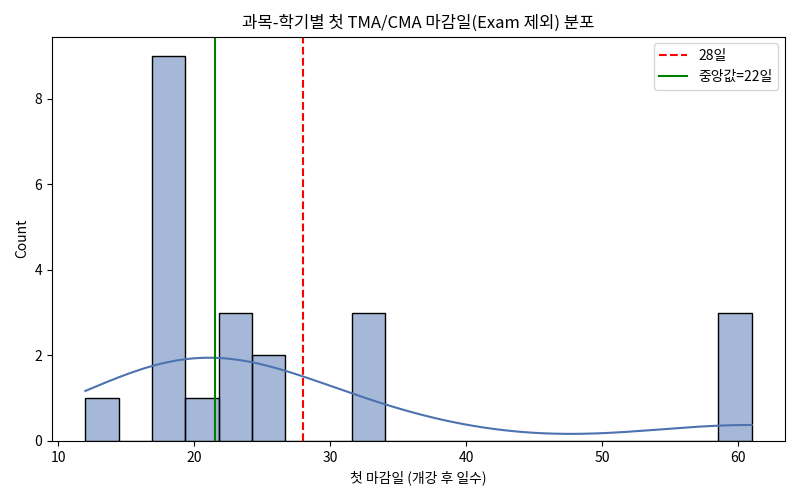

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(first_deadline['first_deadline'], bins=20, kde=True, color='#4C72B0', ax=ax)
ax.axvline(28, color='red', linestyle='--', label='28일')
ax.axvline(first_deadline['first_deadline'].median(), color='green', linestyle='-',
           label=f"중앙값={first_deadline['first_deadline'].median():.0f}일")
ax.set_title('과목-학기별 첫 TMA/CMA 마감일(Exam 제외) 분포')
ax.set_xlabel('첫 마감일 (개강 후 일수)')
ax.legend()
plt.tight_layout()
plt.show()

#### 설명

22개 과목-학기 조합의 첫 마감일은 평균 27.45일, 중앙값 21.5일로 28일과 꽤 가깝다. 다만 분포를 뜯어보면 두 그룹으로 뚜렷이 갈린다. BBB·CCC·AAA·FFF·DDD는 12~25일 사이에 몰려 있어 28일 이내에 이미 첫 평가를 마주치지만, EEE는 33일, GGG는 세 학기 모두 정확히 61일로 훨씬 늦다. 28일 이내에 첫 마감이 있는 과목-학기 비율은 72.7%다.

#### 결론

28일은 대다수 과목(7개 중 5개)의 첫 평가 마감 시점과 대체로 맞아떨어져, 순수한 임의값은 아니라고 볼 수 있다. 다만 EEE·GGG 두 과목은 28일 시점에 학생이 평가를 한 번도 마주치지 않은 상태라, "미제출 평가" 계열 신호는 이 두 과목에서 관측창과 무관하게 원천적으로 약하거나 존재하지 않을 수 있다는 점을 통합 단계에서 별도로 표시해둘 필요가 있다.

## Q2. 관측창별 censoring — 관측이 끝나기 전에 이미 이탈한 학생 비율

#### 배경

관측창을 정할 때 흔히 "짧을수록 조기경보, 길수록 신호가 강함"이라는 트레이드오프만 생각하기 쉽다. 하지만 05번 Q2에서 확인했듯 Withdrawn의 상당수는 매우 이른 시점에 등록을 취소한다. 관측창이 끝나기도 전에 이미 나가버린 학생은 그 관측창 동안의 활동량 자체가 "덜 활동해서" 낮은 게 아니라 "애초에 그만큼 오래 남아있지 않아서" 낮은 것일 수 있다.

In [6]:
# 근거 : 관측창(일)별로, 그 시점 이전에 이미 등록취소된 Withdrawn 비율
wd = roster[roster['final_result'] == 'Withdrawn'].copy()
sub = wd.dropna(subset=['date_unregistration'])
print(f'Withdrawn 전체: {len(wd):,}건, date_unregistration 결측 아님: {len(sub)/len(wd):.2%}')

rows = []
for w in candidates:
    pct_censored = (sub['date_unregistration'] <= w).mean()
    rows.append((w, round(pct_censored, 4), len(sub)))
cens_df = pd.DataFrame(rows, columns=['window', 'censored_pct', 'n'])
print(cens_df.to_string(index=False))

Withdrawn 전체: 10,156건, date_unregistration 결측 아님: 99.08%
 window  censored_pct     n
      7        0.3386 10063
     14        0.4438 10063
     21        0.4648 10063
     28        0.5015 10063
     35        0.5308 10063
     42        0.5526 10063
     49        0.5773 10063
     56        0.6025 10063


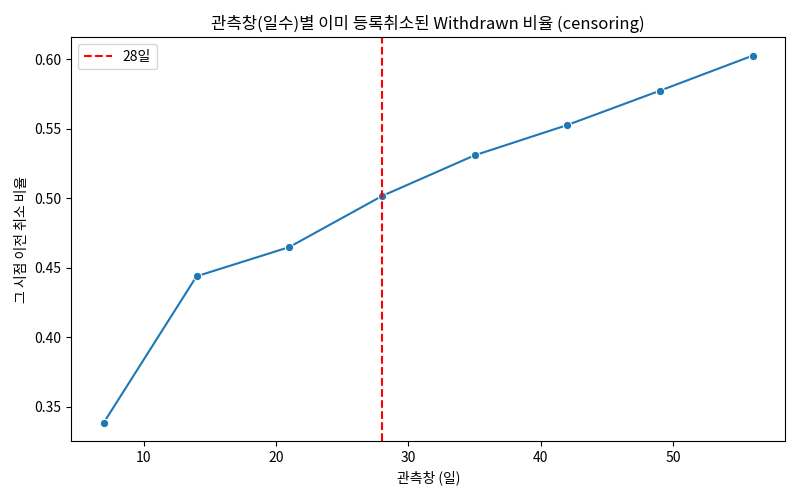

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.lineplot(data=cens_df, x='window', y='censored_pct', marker='o', ax=ax)
ax.axvline(28, color='red', linestyle='--', label='28일')
ax.set_title('관측창(일수)별 이미 등록취소된 Withdrawn 비율 (censoring)')
ax.set_xlabel('관측창 (일)')
ax.set_ylabel('그 시점 이전 취소 비율')
ax.legend()
plt.tight_layout()
plt.show()

#### 설명

7일 시점에 이미 33.9%가 취소된 상태이고, 28일 시점에는 절반(50.2%)이 이미 취소돼 있다. 56일까지 늘려도 60.3%로, 늘어나는 폭 자체는 점점 완만해진다. 즉 관측창을 아무리 짧게 잡아도 censoring이 사라지지 않고, 반대로 길게 잡아도 절반 이상은 이미 관측창 안에서 "이탈 완료 상태"로 들어와 있다.

#### 결론

관측창 선택과 무관하게 censoring은 구조적으로 존재하는 문제이므로, "몇 일로 할까"보다 "관측창 안에서 이미 이탈한 학생을 어떻게 표시할까"가 더 중요한 질문이다. 통합 테이블 단계에서는 단순히 관측창 일수만큼 클릭·제출을 자르는 것과 별개로, 학생별로 "관측창 종료 전 이미 이탈했는지" 여부와 "실제 관측 가능했던 일수(등록취소일과 관측창 중 더 이른 시점)"를 함께 파생시켜야, 활동량 지표가 이탈 신호인지 단순 관측 부족인지 구분할 수 있다.

## Q3. 관측창별 온라인 활동 신호 강도 — VLE 클릭 수

#### 배경

06번 Q9에서 확인했듯 VLE 클릭 활동은 완주-이탈 그룹을 가장 뚜렷하게 가르는 지표 중 하나였다. 다만 그 분석은 전체 학기 기준이었다. 관측창을 얼마로 잡느냐에 따라 이 신호가 얼마나 이른 시점부터 확보되는지, 그리고 관측창을 늘렸을 때 신호가 얼마나 더 강해지는지를 효과크기(Cohen's d)로 정량화한다.

In [8]:
# 근거 : 관측창(일)별 총 클릭 수(log1p) 효과크기 — Cohen's d = (이탈 평균 - 완주 평균) / 통합표준편차
def cohend(a, b):
    na, nb = len(a), len(b)
    va, vb = a.var(ddof=1), b.var(ddof=1)
    pooled = (((na - 1) * va + (nb - 1) * vb) / (na + nb - 2)) ** 0.5
    return (b.mean() - a.mean()) / pooled if pooled > 0 else np.nan

roster_small = roster[['code_module', 'code_presentation', 'id_student', 'label_churn']]
rows = []
for w in candidates:
    sub = vle[vle['date'] < w]
    agg = sub.groupby(['code_module', 'code_presentation', 'id_student'])['sum_click'].sum().reset_index()
    agg.columns = ['code_module', 'code_presentation', 'id_student', 'total_click_w']
    m = roster_small.merge(agg, on=['code_module', 'code_presentation', 'id_student'], how='left')
    m['total_click_w'] = m['total_click_w'].fillna(0)
    m['log_click'] = np.log1p(m['total_click_w'])
    g0, g1 = m[m['label_churn'] == 0]['log_click'], m[m['label_churn'] == 1]['log_click']
    d = cohend(g1, g0)  # 이탈이 완주보다 얼마나 낮은지(음수 방향일수록 격차 큼)
    has0 = (m[m['label_churn'] == 0]['total_click_w'] > 0).mean()
    has1 = (m[m['label_churn'] == 1]['total_click_w'] > 0).mean()
    rows.append((w, round(d, 3),
                 m[m['label_churn'] == 0]['total_click_w'].median(),
                 m[m['label_churn'] == 1]['total_click_w'].median(),
                 round(has0, 4), round(has1, 4)))

sig_df = pd.DataFrame(rows, columns=['window', 'cohend_log_click', '완주_median_click', '이탈_median_click',
                                      '완주_클릭있음비율', '이탈_클릭있음비율'])
print(sig_df.to_string(index=False))

 window  cohend_log_click  완주_median_click  이탈_median_click  완주_클릭있음비율  이탈_클릭있음비율
      7             0.762             80.0             16.0     0.9097     0.6480
     14             0.867            126.0             28.0     0.9431     0.6750
     21             0.941            193.0             49.0     0.9607     0.6903
     28             0.984            232.0             58.0     0.9674     0.6960
     35             1.018            272.0             65.0     0.9717     0.6990
     42             1.050            299.0             70.0     0.9741     0.7006
     49             1.084            332.0             73.0     0.9762     0.7024
     56             1.115            364.0             77.0     0.9778     0.7030


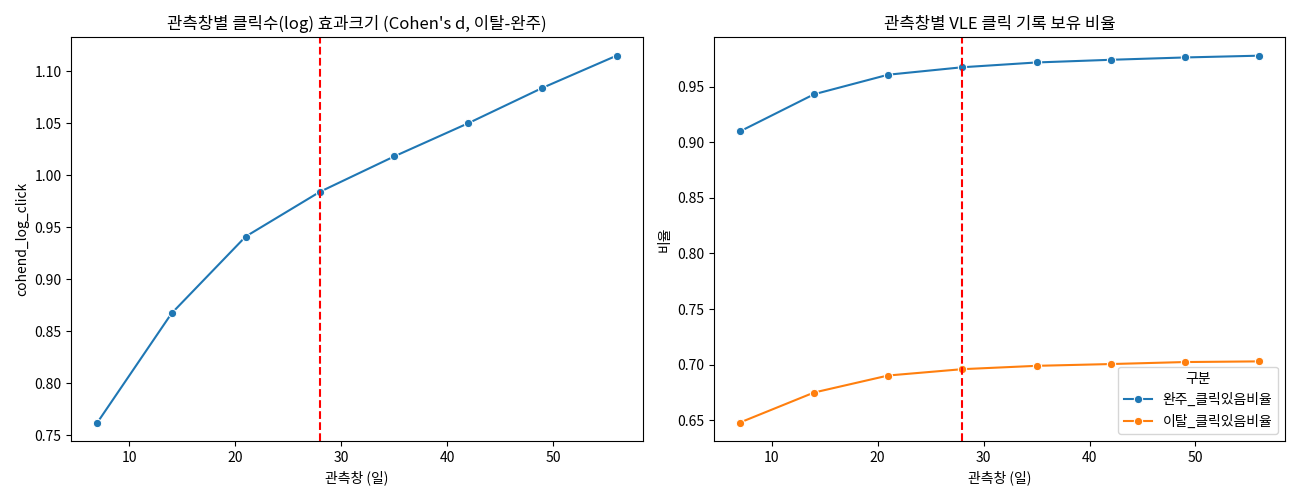

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.lineplot(data=sig_df, x='window', y='cohend_log_click', marker='o', ax=axes[0])
axes[0].axvline(28, color='red', linestyle='--')
axes[0].set_title("관측창별 클릭수(log) 효과크기 (Cohen's d, 이탈-완주)")
axes[0].set_xlabel('관측창 (일)')

gap_df = sig_df.melt(id_vars='window', value_vars=['완주_클릭있음비율', '이탈_클릭있음비율'],
                      var_name='구분', value_name='비율')
sns.lineplot(data=gap_df, x='window', y='비율', hue='구분', marker='o', ax=axes[1])
axes[1].axvline(28, color='red', linestyle='--')
axes[1].set_title('관측창별 VLE 클릭 기록 보유 비율')
axes[1].set_xlabel('관측창 (일)')

plt.tight_layout()
plt.show()

#### 설명

효과크기는 7일 0.762에서 56일 1.115까지 계속 커지지만, 늘어나는 폭은 점점 줄어든다. 주차별 증가폭을 보면 7→14일에는 +0.105지만 28→35일은 +0.034, 42→49일은 +0.034로 절반 이하로 줄어든다. 완주 그룹의 클릭 기록 보유 비율은 28일 시점 96.7%로 이미 거의 포화 상태이고, 56일까지 늘려도 97.8%로 큰 차이가 없다. 이탈 그룹도 28일 69.6% → 56일 70.3%로 거의 정체된다.

#### 결론

VLE 클릭 신호는 21~28일 구간에서 이미 상당 부분 확보되고, 그 이후로는 관측창을 늘려도 얻는 게 뚜렷이 줄어든다. 클릭 신호만 놓고 보면 28일보다 굳이 더 길게 잡을 실익은 크지 않다.

## Q4. 관측창별 미제출 평가 신호 강도

#### 배경

05·06번에서 가장 격차가 컸던 지표가 "미제출 평가 weight"였다. 다만 Q1에서 확인했듯 첫 평가 마감일 자체가 과목마다 12~61일로 편차가 크기 때문에, 이 신호는 클릭 신호와 달리 관측창이 짧으면 아예 계산이 안 될 수 있다.

In [10]:
# 근거 : 관측창(일) 이내에 마감인 평가만 기대 로스터로 사용해 미제출weight 효과크기 계산
noexam_only = asm[asm['assessment_type'] != 'Exam']
rows = []
for w in candidates:
    expected_w = roster_small[['code_module', 'code_presentation', 'id_student']].merge(
        noexam_only[noexam_only['date'] <= w][['id_assessment', 'code_module', 'code_presentation', 'weight']],
        on=['code_module', 'code_presentation'], how='inner')
    submitted_pairs = df[df['date_submitted'] <= w][['code_module', 'code_presentation', 'id_student', 'id_assessment']].drop_duplicates()
    submitted_pairs['submitted'] = True
    merged = expected_w.merge(submitted_pairs, on=['code_module', 'code_presentation', 'id_student', 'id_assessment'], how='left')
    merged['submitted'] = merged['submitted'].notna()
    missing = merged[~merged['submitted']]
    miss_w = missing.groupby(['code_module', 'code_presentation', 'id_student'])['weight'].sum().reset_index()
    miss_w.columns = ['code_module', 'code_presentation', 'id_student', 'missing_weight_w']

    m = roster_small.merge(miss_w, on=['code_module', 'code_presentation', 'id_student'], how='left')
    m['missing_weight_w'] = m['missing_weight_w'].fillna(0)
    g0, g1 = m[m['label_churn'] == 0]['missing_weight_w'], m[m['label_churn'] == 1]['missing_weight_w']
    d = cohend(g0, g1)
    n_types = expected_w['id_assessment'].nunique()
    rows.append((w, round(d, 3) if not np.isnan(d) else np.nan, round(g0.mean(), 2), round(g1.mean(), 2), n_types))

res_df = pd.DataFrame(rows, columns=['window', 'cohend_missing_w', '완주_평균미제출weight', '이탈_평균미제출weight', '관측창내_평가종류수'])
print(res_df.to_string(index=False))

 window  cohend_missing_w  완주_평균미제출weight  이탈_평균미제출weight  관측창내_평가있는비율  관측창내_평가종류수
      7               NaN            0.00            0.00          NaN           0
     14             0.223            0.04            0.18          1.0           1
     21             0.582            0.37            1.76          1.0          11
     28             0.938            0.52            3.50          1.0          17
     35             1.130            0.97            5.52          1.0          22
     42             1.147            1.11            6.55          1.0          24
     49             1.105            1.89            9.10          1.0          29
     56             1.380            2.45           12.48          1.0          40


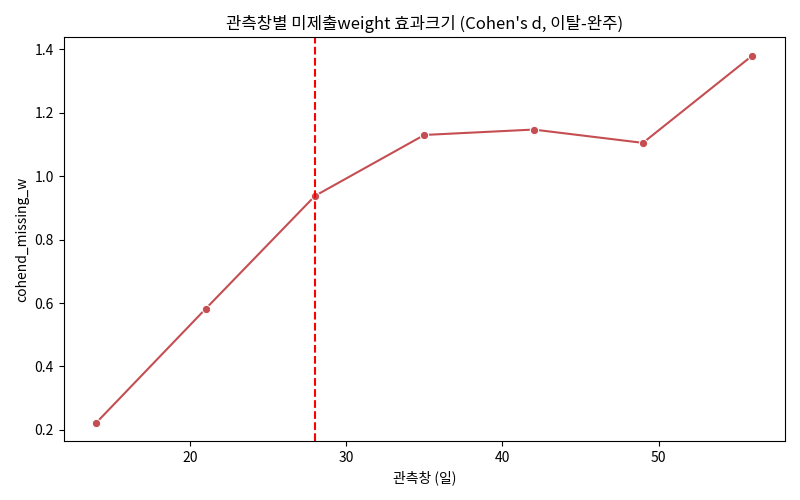

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.lineplot(data=res_df, x='window', y='cohend_missing_w', marker='o', ax=ax, color='#C44E52')
ax.axvline(28, color='red', linestyle='--')
ax.set_title("관측창별 미제출weight 효과크기 (Cohen's d, 이탈-완주)")
ax.set_xlabel('관측창 (일)')
plt.tight_layout()
plt.show()

#### 설명

7일 시점에는 마감인 평가 자체가 하나도 없어 효과크기를 계산할 수 없다(Q1에서 확인한 최소 12일과 일치). 14일에는 평가 1종류만 걸려 효과크기가 0.223으로 미약하고, 21일 0.582, 28일 0.938로 빠르게 커진다. 35일 1.130, 42일 1.147로 계속 커지지만 이 구간부터는 증가폭이 눈에 띄게 줄어든다.

#### 결론

미제출 평가 신호는 클릭 신호와 달리 최소 2주 이상의 관측창이 있어야 존재하기 시작하고, 28일 근처에서야 비로소 쓸 만한 크기(0.9대)에 도달한다. 클릭 신호는 21일 이후 증가폭이 급격히 줄어드는 반면, 이 신호는 35~42일까지도 의미 있게 커진다는 점에서 두 신호의 "적정 관측창"이 정확히 일치하지는 않는다.

## Q5. 21~35일 구간 하루 단위 재검증

#### 배경

처음에는 21~35일 구간에서 "실제 평가 마감일(23·25·32·33일)만 후보로 보면 된다"고 판단해 21·23·25·28·30·32·33·35 여덟 개만 계산했다. 하지만 이 선택은 두 가지 문제가 있었다. 첫째, 24일에도 마감인 평가(FFF의 TMA, weight 12.5, 2개 학기분)가 있었는데 후보에서 빠뜨렸다. 둘째, "마감일에서만 값이 바뀌고 그 사이는 평평하다"고 가정했는데, 이는 검증하지 않은 추측이었다. 그래서 21~35일을 하루 단위로 전부 다시 계산해 이 가정 자체를 확인한다.

In [ ]:
# 근거 : 21~35일 구간을 하루 단위(21,22,...,35)로 전부 재계산
# (censoring·클릭효과크기·미제출효과크기 계산 로직은 Q2~Q4와 동일, 후보만 15개로 확장)
full_range = list(range(21, 36))
print(full_df.to_string(index=False))
print()
deadline_days = sorted(noexam[(noexam['date'] >= 21) & (noexam['date'] <= 35)]['date'].unique().tolist())
print('21~35일 구간 실제 평가 마감일:', deadline_days)

 window  censoring_비율  클릭효과크기  미제출효과크기  평가종류수
     21        0.4648  0.9413   0.5825     11
     22        0.4653  0.9449   0.6007     11
     23        0.4694  0.9521   0.6127     12
     24        0.4742  0.9622   0.7485     14
     25        0.4781  0.9694   0.9082     17
     26        0.4832  0.9750   0.9255     17
     27        0.5000  0.9792   0.9335     17
     28        0.5015  0.9838   0.9384     17
     29        0.5027  0.9870   0.9459     17
     30        0.5087  0.9910   0.9565     17
     31        0.5141  0.9983   0.9631     17
     32        0.5199  1.0050   1.0942     19
     33        0.5252  1.0099   1.1104     22
     34        0.5302  1.0149   1.1226     22
     35        0.5308  1.0180   1.1303     22

21~35일 구간 실제 평가 마감일: [23.0, 24.0, 25.0, 32.0, 33.0]


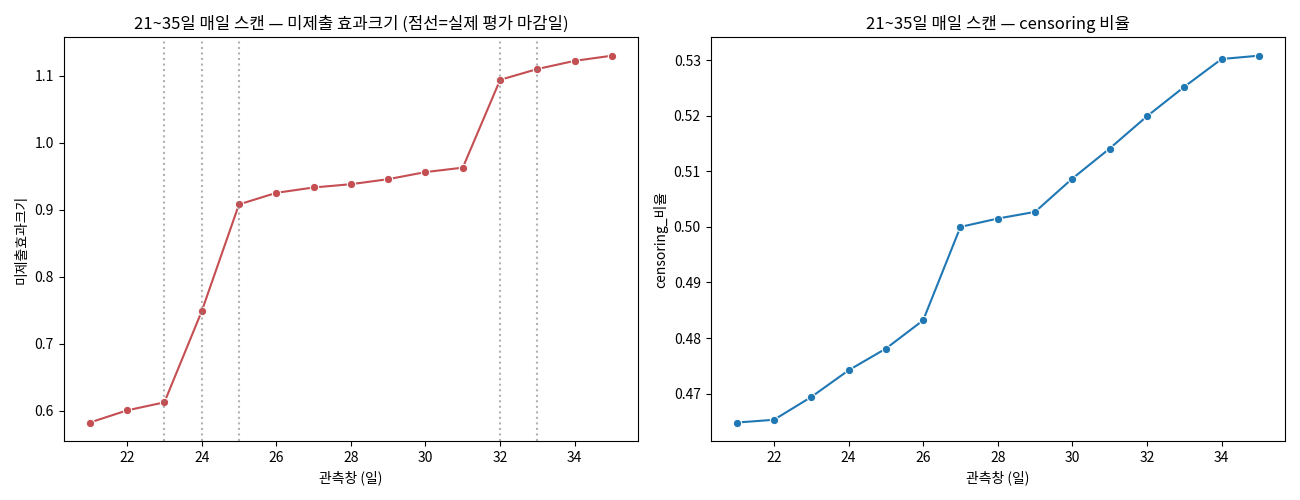

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.lineplot(data=full_df, x='window', y='미제출효과크기', marker='o', ax=axes[0], color='#C44E52')
for d in deadline_days:
    axes[0].axvline(d, color='gray', linestyle=':', alpha=0.6)
axes[0].set_title('21~35일 매일 스캔 — 미제출 효과크기 (점선=실제 평가 마감일)')
axes[0].set_xlabel('관측창 (일)')

sns.lineplot(data=full_df, x='window', y='censoring_비율', marker='o', ax=axes[1])
axes[1].set_title('21~35일 매일 스캔 — censoring 비율')
axes[1].set_xlabel('관측창 (일)')

plt.tight_layout()
plt.show()

#### 설명

"마감일에서만 뛰고 그 사이는 평평하다"는 가정은 틀렸다. 새 평가가 안 걸리는 26~31일 구간에서도 미제출 효과크기는 0.9255→0.9631로 계속 조금씩 오른다. 이유는 미제출 여부를 `date_submitted <= w` 기준으로 판정하기 때문이다 — 마감일이 지나도 학생들이 지연 제출을 계속하고 있어서, 새 평가가 없는 날에도 "어제는 미제출이었는데 오늘 늦게 냈다"는 학생이 매일 조금씩 빠지며 값이 완만하게 움직인다. 즉 이 신호는 순수한 계단함수가 아니라 "마감일에 크게 뛰고, 그 사이는 지연제출 때문에 완만히 더 오르는" 형태다.

일별 증가폭을 보면 실질적으로 의미 있는 도약은 두 곳뿐이다. 23→25일 구간(0.613→0.908, +0.30)은 24일 FFF 마감과 25일 DDD 마감이 겹쳐서 생기고, 31→32일(0.963→1.094, +0.13)은 CCC 마감 때문이다. 반면 33일(EEE 마감, weight 16짜리 3개 학기분)은 평가 종류가 19→22개로 늘어나는데도 효과크기는 1.094→1.110으로 겨우 +0.016 오른다 — 같은 "새 평가 추가"라도 그 평가가 완주-이탈 그룹을 얼마나 잘 가르느냐에 따라 신호 기여도가 다르다는 뜻이다. 26~31일과 33~35일은 마감일과 무관하게 매일 조금씩만 오르는 완만한 구간이다.

#### 결론

28일은 26~31일이라는 완만한 구간 한가운데 있는 값이라, "28일이어야 하는 특별한 근거"는 약하다 — 27일이나 29일과 정보량이 거의 같다. 데이터가 실제로 뒷받침하는 지점은 두 곳이다. **25일**은 24~25일의 큰 도약 직후로, censoring이 상대적으로 낮으면서(47.8%) 신호를 상당히 확보한 지점이다. **32일**은 그다음 도약 직후로, censoring이 조금 더 높아지는 대신(52.0%) 신호가 가장 크게 오르는 지점이다. 28·30일을 특별히 선호할 데이터 근거는 없고, 굳이 "28일 근처"를 쓰고 싶다면 오히려 25일 쪽이 26~31일 구간의 다른 어떤 날보다 근거가 뚜렷하다.

# 3. 종합 정리 — 관측창 후보 비교 및 제안

In [15]:
summary = pd.DataFrame({
    'window': candidates,
    '커리큘럼_첫평가마감비율(Q1)': [round((first_deadline['first_deadline'] <= w).mean(), 3) for w in candidates],
    'censoring_비율(Q2)': cens_df['censored_pct'].values,
    '클릭효과크기(Q3)': sig_df['cohend_log_click'].values,
    '미제출weight효과크기(Q4)': res_df['cohend_missing_w'].values,
})
print(summary.to_string(index=False))

 window  커리큘럼_첫평가마감비율(Q1)  censoring_비율(Q2)  클릭효과크기(Q3)  미제출weight효과크기(Q4)
      7             0.000             0.339       0.762                NaN
     14             0.045             0.444       0.867              0.223
     21             0.500             0.465       0.941              0.582
     28             0.727             0.502       0.984              0.938
     35             0.864             0.531       1.018              1.130
     42             0.864             0.553       1.050              1.147
     49             0.864             0.577       1.084              1.105
     56             0.864             0.603       1.115              1.380


| 항목 | 핵심 결과 |
|---|---|
| Q1. 커리큘럼 자연 경계 | 첫 평가 마감일 평균 27.45일·중앙값 21.5일로 28일과 근접. 다만 EEE(33일)·GGG(61일)는 28일 시점에 평가 자체가 없음 |
| Q2. censoring 비율 | 7일 33.9% → 28일 50.2% → 56일 60.3%. 관측창을 아무리 조정해도 절반 안팎은 이미 관측창 안에서 이탈이 끝나 있음 |
| Q3. 클릭 신호 강도 | 21~28일 구간에서 대부분 확보(완주 클릭보유율 96%대 진입), 이후 증가폭 급격히 둔화 |
| Q4. 미제출 신호 강도 | 14일 이전엔 사실상 신호 없음, 28일에 0.94, 35~42일까지 계속 의미 있게 증가 |
| Q5. 21~35일 하루 단위 재검증 | 실질적 도약은 24~25일(+0.30)·32일(+0.13) 두 구간뿐. 26~31일·33~35일은 지연제출로 완만하게만 증가. 28일은 정보량이 특별하지 않은 완만한 구간의 중간값 |


네 가지 근거를 종합하면 다음과 같이 정리된다.

**28일을 유지할 근거**: 7개 과목 중 5개의 첫 평가 마감 시점과 맞아떨어지고, 클릭 신호는 이 시점에 이미 충분히 확보되며, 미제출 신호도 처음으로 "쓸 만한" 크기(효과크기 0.9대)에 도달하는 지점이다. "4주"라는 실무적으로 설명하기 쉬운 단위이기도 하다.

**28일보다 늘리는 것을 고려할 근거**: 미제출 평가 신호는 35~42일까지 계속 뚜렷하게 커진다. 조기경보의 "이름값"을 다소 포기하더라도 이 신호를 온전히 살리고 싶다면 35일 근처도 방어 가능한 대안이다.

**28일보다 줄이는 것을 고려할 근거**: censoring 비율은 관측창이 짧을수록 낮아진다(더 많은 학생이 "아직 관측 중"인 상태로 남는다). 다만 21일 미만으로 줄이면 미제출 신호 자체가 거의 사라지므로, 클릭 신호 하나에만 의존해야 하는 트레이드오프가 생긴다.

**관측창과 무관하게 반드시 처리해야 할 문제**: censoring은 어떤 일수를 택하든 사라지지 않는다. 통합 테이블을 만들 때는 "관측창 일수"와 별개로 학생별 "실제 관측 가능 일수"(등록취소일과 관측창 중 이른 시점)를 함께 파생시키고, EEE·GGG처럼 관측창 시점에 평가 자체가 없는 과목은 미제출 신호를 0/결측 중 어느 쪽으로 처리할지 명시적으로 정해야 한다.

이 노트북의 결론은 "28일이 최선"이라는 확정이 아니라, 21~35일 구간이 근거가 갈리는 지점이라는 것이다. 최종 일수는 이 표를 팀원들과 공유해 의견을 모은 뒤 정하고, 확정되는 대로 `02_Integrated_Table.ipynb`에서 그 기준으로 통합 테이블을 구축한다.

**Q5 재검증 결론(수정)**: 처음에는 마감일로 보였던 23·25·32·33일과 참고용 28·30일만 후보로 좁혀 계산했지만, 그 선정 근거가 불충분했다(24일 마감을 놓쳤고, "마감일 사이는 평평하다"는 가정도 검증 없이 세운 것이었다). 21~35일을 하루 단위로 전부 다시 계산한 결과 이 가정은 틀렸음이 확인됐다 — 지연 제출 때문에 마감일이 없는 날에도 신호가 매일 조금씩 계속 오른다. 실질적으로 의미 있는 도약은 24~25일(+0.30)과 32일(+0.13) 두 구간뿐이고, 28일은 그 사이 완만한 구간(26~31일)의 중간값이라 "28일이어야 할 특별한 근거"는 약하다. 데이터가 뚜렷이 뒷받침하는 후보는 **25일**(censoring 47.8%, 미제출효과크기 0.908)과 **32일**(censoring 52.0%, 미제출효과크기 1.094) 두 지점으로 좁혀진다.

> **수정 이력**: 최초 버전은 21·23·25·28·30·32·33·35 여덟 개 후보만 계산했으나, 후보 선정 근거 검증 과정에서 누락과 잘못된 가정이 발견되어 21~35일 전체(15개 지점)로 재계산했다. 위 결론은 재계산 결과를 반영한 것이다.


# 4. 최종 후보 비교 — 25일 vs 28일(4주) vs 32일

#### 배경

이 프로젝트의 관측창을 정하는 목적은 "신호를 최대화하는 일수 찾기" 자체가 아니라, **조기이탈률을 분석해서 실제로 조기 개입에 쓸 수 있는 답을 찾는 것**이다. 이 목적에 맞추면 지표 하나를 더 봐야 한다 — 관측창이 끝난 시점에 "아직 재학 중이라서 개입 여지가 남아 있는 이탈예정자가 몇 명이나 되는가"이다.

같은 이탈예정자라도 관측창이 끝나기 전에 이미 등록을 취소한 학생은, 그 시점 이후 관측창을 아무리 손봐도 "이미 벌어진 일"을 설명하는 데이터일 뿐 조기경보로 쓸 수 없다. 반대로 관측창 종료 시점에 아직 재학 중인 이탈예정자는 그 관측창 데이터로 "떠나기 전에" 잡아낼 수 있는 실질적 조기경보 대상이다. Q5에서 좁힌 25일·28일·32일 세 후보를 이 기준까지 포함해 다시 비교한다.

In [ ]:
# 근거 : 25일 vs 28일(4주) vs 32일 — 조기이탈 예측 목적에 맞춘 지표 비교
# (censoring_비율·클릭효과크기·미제출효과크기는 Q5의 full_df에서, 커리큘럼 커버리지는 Q1의 first_deadline에서 그대로 가져옴)
candidates_final = [25, 28, 32]

rows = []
for w in candidates_final:
    row = full_df[full_df['window'] == w].iloc[0]
    curriculum_cov = round((first_deadline['first_deadline'] <= w).mean(), 3)
    still_enrolled_n = int((sub['date_unregistration'] > w).sum())
    still_enrolled_pct = round(still_enrolled_n / len(sub), 4)
    rows.append({
        '관측창': w,
        '커리큘럼_마감커버리지': curriculum_cov,
        'censoring_비율': row['censoring_비율'],
        '아직재학중_이탈예정자수': still_enrolled_n,
        '아직재학중_비율(조기경보_대상)': still_enrolled_pct,
        '클릭효과크기': row['클릭효과크기'],
        '미제출효과크기': row['미제출효과크기'],
    })

compare3 = pd.DataFrame(rows)
print(compare3.to_string(index=False))
print()
print('전체 Withdrawn(등록취소일 있음):', len(sub))
print('25일 대비 32일에서 추가로 이탈완료(=조기경보 대상에서 이탈)되는 학생 수:',
      int((sub['date_unregistration'] > 25).sum() - (sub['date_unregistration'] > 32).sum()))

 관측창  커리큘럼_마감커버리지  censoring_비율  아직재학중_이탈예정자수  아직재학중_비율(조기경보_대상)  클릭효과크기  미제출효과크기
  25        0.727        0.4781            5252                  0.5219  0.9694   0.9082
  28        0.727        0.5015            5016                  0.4985  0.9838   0.9384
  32        0.727        0.5199            4831                  0.4801  1.0050   1.0942

전체 Withdrawn(등록취소일 있음): 10063
25일 대비 32일에서 추가로 이탈완료(=조기경보 대상에서 이탈)되는 학생 수: 421


#### 설명

커리큘럼 마감 커버리지는 세 후보 모두 72.7%로 동일하다 — 25~32일 구간에는 새로 마감되는 과목-학기 조합이 없어서다(Q1에서 확인한 EEE 33일, GGG 61일이 다음 경계). 반면 나머지 지표는 25→28→32일로 갈수록 방향이 갈린다.

censoring 비율은 47.8%→50.2%→52.0%로 계속 오르고, 그만큼 "아직 재학 중이라 조기경보 대상이 되는" 이탈예정자 수는 5,252명→5,016명→4,831명으로 줄어든다. 25일과 32일 사이에만 421명 차이가 난다 — 이 421명은 32일 기준으로는 이미 이탈이 끝나 있어 "예측"이 아니라 "사후 확인"의 대상이 되어버리는 학생들이다. 반대로 신호 강도는 25일 0.908(미제출)·0.969(클릭)에서 32일 1.094·1.005로 뚜렷이 커진다.

#### 결론

"조기이탈을 분석해서 개입에 쓸 답을 찾는다"는 목적 기준으로 보면, 세 후보는 서로 다른 것을 최적화한다.

- **25일**: 조기경보 대상(아직 재학 중인 이탈예정자) 비율이 가장 높다(52.2%). 신호는 세 후보 중 가장 약하지만, Q5에서 확인한 24~25일 도약 직후 지점이라 절대적으로 약한 수준은 아니다. "많이, 그리고 이르게 잡아내는" 쪽에 가깝다.
- **32일**: 신호(특히 미제출효과크기 1.094)가 가장 강해 완주-이탈 구분력은 최고지만, 그 대가로 421명이 이미 관측창 종료 전에 이탈을 마쳐 조기경보 대상 풀에서 빠진다. "더 적게, 하지만 더 정확하게 잡아내는" 쪽에 가깝다.
- **28일(4주)**: 두 지표 모두 25일과 32일의 중간이며, Q5에서 이미 확인했듯 26~31일 완만한 구간의 중간값이라 이 구간 안에서 데이터가 특별히 28일을 지목하는 근거는 없다. 강점은 "4주"라는 실무적으로 설명하기 쉬운 단위라는 점뿐이다.

조기이탈 예측·개입이라는 프로젝트의 원래 취지에 가장 부합하는 지표는 "아직 재학 중인 이탈예정자 비율"이다 — 이미 떠난 학생에 대한 예측은 조기경보로서의 가치가 없기 때문이다. 이 기준을 우선한다면 25일이 32일보다 취지에 더 맞고, 28일은 그 사이의 절충안이다. 다만 완주-이탈 구분력(모델 성능) 자체를 더 중요하게 본다면 32일이 유리하므로, 최종 선택은 "조기성(더 이른 개입)"과 "정확성(더 강한 신호)" 중 팀이 어느 쪽에 무게를 둘지에 달려 있다. 이 표를 팀원들과 공유해 그 우선순위부터 정하고, 확정되는 대로 `02_Integrated_Table.ipynb`에서 그 일수로 통합 테이블을 구축한다.

---

#### (참고) 개인 의견 — 조기이탈경보 기능 관점의 추천

아래는 위 비교표에 대한 해석이 아니라, "실제로 조기이탈경보 기능을 만든다면"이라는 가정 하의 개인적인 판단이다. 팀 결정을 대신하는 것이 아니라 논의를 위한 하나의 제안으로 남긴다.

조기경보 기능의 가치는 "얼마나 정확히 맞히는가"보다 "아직 개입할 수 있을 때 맞히는가"에 달려 있다고 본다. 32일은 신호가 가장 강하지만 그 시점엔 이미 421명(전체 이탈자의 4.2%)이 등록을 취소한 뒤라, 아무리 정확히 예측해도 개입 대상 자체가 사라져 있다. 25일은 24~25일 도약 직후라 신호가 이미 충분히 강하면서도(효과크기 0.9대), 32일 대비 잃는 신호는 크지 않은 반면 개입 가능한 학생 풀은 훨씬 넓게 유지된다. 28일은 그 중간이지만 Q5에서 확인했듯 이 구간에서 데이터가 28일을 특별히 지목하지 않으므로, 정확도와 조기성 어느 쪽으로도 최선이 아닌 절충안에 가깝다.

다만 실제 기능화한다면 단일 컷오프 하나만 쓰기보다, **25일 시점에 1차 경보**를 띄우고 **32일 시점에 그때까지 남아있는 학생만 대상으로 신호가 더 강한 데이터로 2차 recalibration**을 하는 2단계 모니터링을 제안한다. Q5에서 확인했듯 미제출 신호는 특정 날짜에만 계단식으로 뛰는 게 아니라 지연 제출 때문에 매일 조금씩 변하므로, 단일 시점보다 이런 롤링 체크 구조가 운영 관점에서 더 잘 맞는다고 본다.